1. Introdução

Este notebook tem como objetivo realizar uma Exploratory Data Analysis (EDA) sobre um conjunto específico de dados provenientes do repositório público:

repositorio:

[texto do link](https://)

2. Justificação e Contexto do Dataset

O dataset em questão é uma coleção de medições de aptidão física e características demográficas, com o objetivo de classificar um indivíduo numa das classes de desempenho.

Variável-Alvo (class): A coluna class (A, B, C, D) é a variável que pretendemos prever.

Variáveis Preditivas (Features): Incluem características demográficas (age, gender), medidas corporais (height_cm, weight_kg, body fat_%), métricas de saúde (diastolic, systolic) e resultados de testes físicos (gripForce, sit and bend forward_cm, sit-ups counts, broad jump_cm).

Contexto da Classificação: Para modelos de classificação, o EDA deve concentrar-se em:

Distribuição da Classe: O dataset está equilibrado?

Diferenças entre Classes: As features numéricas têm distribuições diferentes para cada classe?

Relação Feature-Classe: Que features parecem ser as mais discriminatórias?

3. Estrutura do Notebook e Objetivos da EDA

O notebook de EDA deve seguir uma estrutura lógica, focada na preparação para modelos de classificação.

Objetivos:

- Explorar a Estrutura: Verificar dimensões, tipos de dados e valores em falta.

- Analisar a Variável-Alvo (class): Entender a distribuição de classes e o potencial desequilíbrio.

- Análise Descritiva e Distribuições:

  - Estatísticas descritivas das variáveis numéricas.

  - Distribuição das features mais relevantes.

- Análise Bivariada (Feature vs. Target):

  - Como as features numéricas variam entre as diferentes classes (class).

  - Relação da variável categórica (gender) com a class.

- Preparação de Dados: Identificação de outliers e preparação da variável categórica.

In [ ]:
# Simulação de carregamento (em Python)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


dataset_path = "bodyPerformance.csv"
df = pd.read_csv(dataset_path)

print("Dimensões do Dataset:", df.shape)
print("\nTipos de Dados:")
print(df.dtypes)
print("\nValores em falta:")
print(df.isna().sum())
print("\nEstatísticas Descritivas:")
print(df.describe())

Dimensões do Dataset: (13393, 12)

Tipos de Dados:
age                        float64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object

Valores em falta:
age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

Estatísticas Descritivas:
                age     height_cm     weight_kg    body fat_%     diastolic  \
count  13393.000000  13393.00

Contagem de Classes:
class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64


/tmp/ipython-input-1243847589.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, order=class_counts.index, palette='viridis')


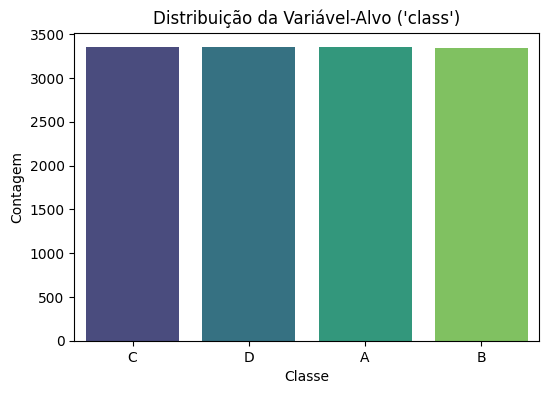

In [ ]:
# Distribuição da variável-alvo
class_counts = df['class'].value_counts()

print("Contagem de Classes:")
print(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, order=class_counts.index, palette='viridis')
plt.title("Distribuição da Variável-Alvo ('class')")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show() #

/tmp/ipython-input-703188127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=feature, data=df, order=class_counts.index, palette='plasma')
/tmp/ipython-input-703188127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=feature, data=df, order=class_counts.index, palette='plasma')
/tmp/ipython-input-703188127.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=feature, data=df, order=class_counts.index, palette='plasma')


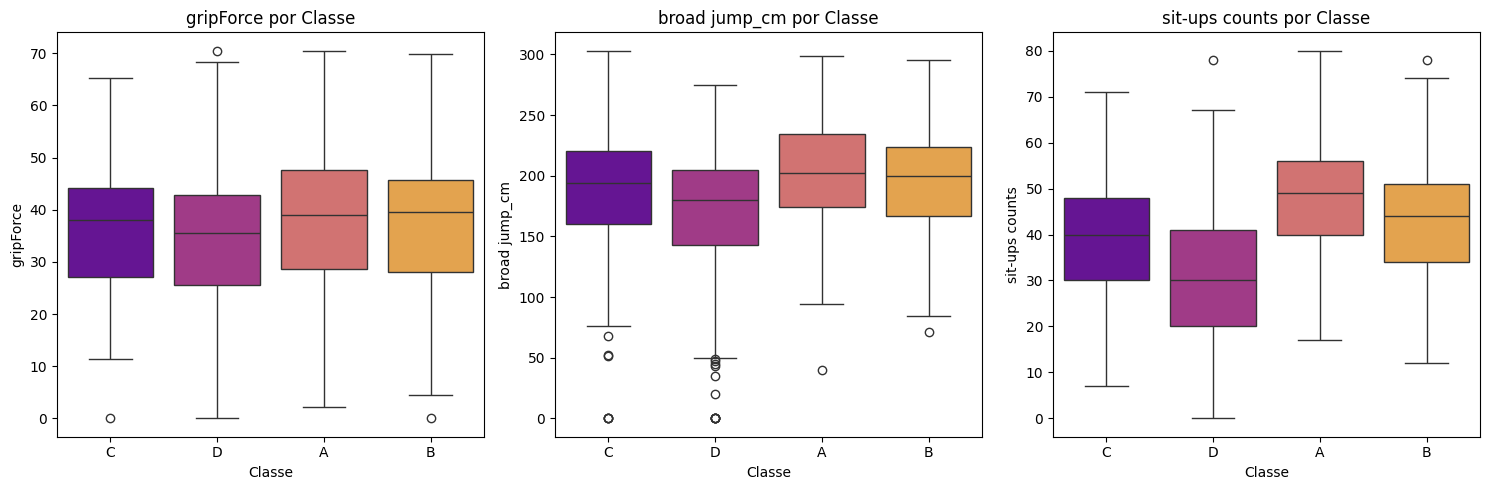

In [ ]:
# Boxplots para as métricas físicas vs. a Classe
key_features = ['gripForce', 'broad jump_cm', 'sit-ups counts']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(key_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='class', y=feature, data=df, order=class_counts.index, palette='plasma')
    plt.title(f'{feature} por Classe')
    plt.xlabel('Classe')
    plt.ylabel(feature)

plt.tight_layout()
plt.show() #

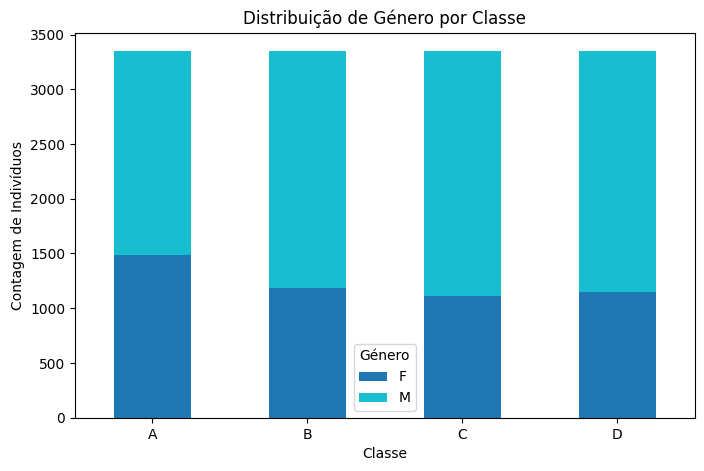

In [ ]:
# Distribuição de género por classe
gender_class_pivot = df.groupby(['class', 'gender']).size().unstack(fill_value=0)
gender_class_pivot.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab10')
plt.title("Distribuição de Género por Classe")
plt.xlabel("Classe")
plt.ylabel("Contagem de Indivíduos")
plt.xticks(rotation=0)
plt.legend(title='Género')
plt.show() #

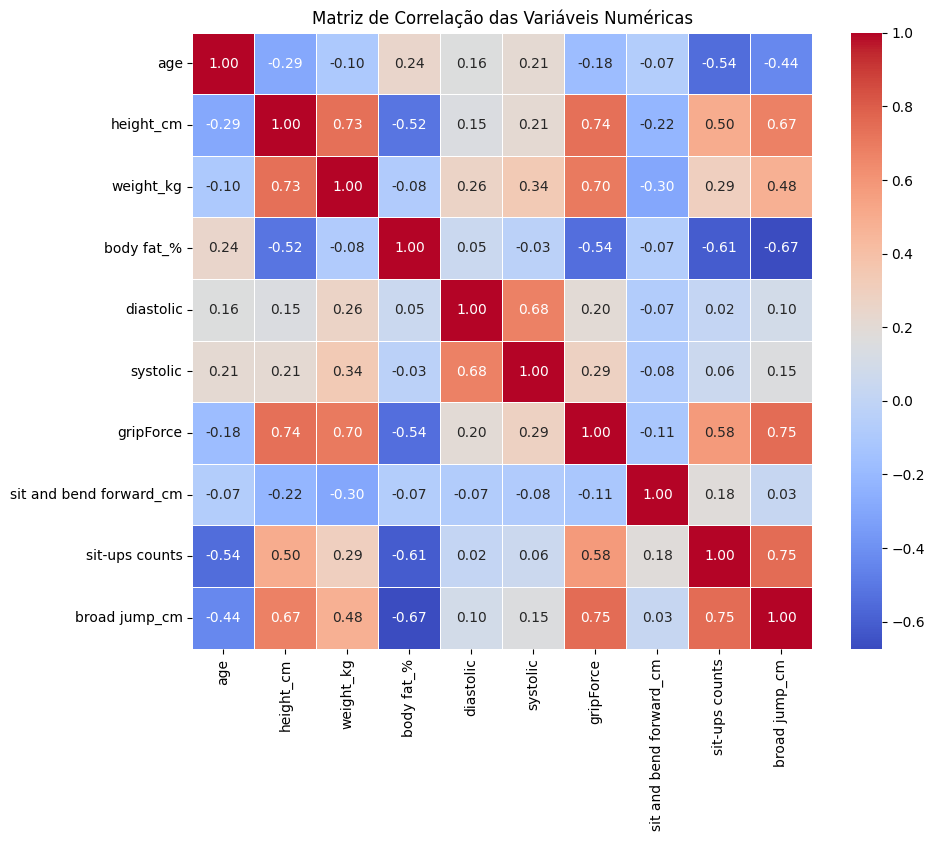

In [ ]:
# Selecionar colunas numéricas (excluindo 'class' e 'gender')
numeric_df = df.drop(columns=['gender', 'class'])

# Calcular e visualizar a matriz de correlação
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show() #

In [ ]:
# 1. Codificação de Género (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['gender'], drop_first=True) # Cria 'gender_M' e 'gender_F' (se 'drop_first=False')
# Neste caso, 'gender_M' é a variável criada (1 para Masculino, 0 para Feminino).

# 2. Separação X e y
X = df_encoded.drop('class', axis=1) # Todas as colunas exceto 'class'
y = df_encoded['class'] # Variável-alvo

print("\nPré-visualização de X (Features):")
print(X.head())


Pré-visualização de X (Features):
    age  height_cm  weight_kg  body fat_%  diastolic  systolic  gripForce  \
0  27.0      172.3      75.24        21.3       80.0     130.0       54.9   
1  25.0      165.0      55.80        15.7       77.0     126.0       36.4   
2  31.0      179.6      78.00        20.1       92.0     152.0       44.8   
3  32.0      174.5      71.10        18.4       76.0     147.0       41.4   
4  28.0      173.8      67.70        17.1       70.0     127.0       43.5   

   sit and bend forward_cm  sit-ups counts  broad jump_cm  gender_M  
0                     18.4            60.0          217.0      True  
1                     16.3            53.0          229.0      True  
2                     12.0            49.0          181.0      True  
3                     15.2            53.0          219.0      True  
4                     27.1            45.0          217.0      True  


In [ ]:
# --- 3. Renomear para clareza e preparar para exportação ---
# Assumindo que 'gender_M' foi criada, vamos renomeá-la para ser mais descritiva.
# Nota: Esta linha só é necessária se a coluna não foi renomeada anteriormente.
if 'gender_M' in df_encoded.columns:
    df_encoded.rename(columns={'gender_M': 'is_male'}, inplace=True)
elif 'gender_F' in df_encoded.columns:
    df_encoded.rename(columns={'gender_F': 'is_female'}, inplace=True)


# --- 4. Exportação do DataFrame Codificado ---
output_path = "prepared_classification.csv"

# Exportar o DataFrame completo (features e target) para um ficheiro CSV
df_encoded.to_csv(output_path, index=False)

print("\n--- FASE DE EXPORTAÇÃO CONCLUÍDA ---")
print(f"Dataset preparado para Classificação guardado com sucesso em: {output_path}")
print("O ficheiro contém todas as features e a variável-alvo 'class'.")
print("A coluna 'gender' foi substituída por 'is_male' (ou similar) e está pronta para modelagem.")

# Opcional: Mostrar as primeiras linhas do ficheiro que seria guardado
print("\nPré-visualização do ficheiro exportado (df_encoded.head()):")
print(df_encoded.head())


--- FASE DE EXPORTAÇÃO CONCLUÍDA ---
Dataset preparado para Classificação guardado com sucesso em: prepared_classification.csv
O ficheiro contém todas as features e a variável-alvo 'class'.
A coluna 'gender' foi substituída por 'is_male' (ou similar) e está pronta para modelagem.

Pré-visualização do ficheiro exportado (df_encoded.head()):
    age  height_cm  weight_kg  body fat_%  diastolic  systolic  gripForce  \
0  27.0      172.3      75.24        21.3       80.0     130.0       54.9   
1  25.0      165.0      55.80        15.7       77.0     126.0       36.4   
2  31.0      179.6      78.00        20.1       92.0     152.0       44.8   
3  32.0      174.5      71.10        18.4       76.0     147.0       41.4   
4  28.0      173.8      67.70        17.1       70.0     127.0       43.5   

   sit and bend forward_cm  sit-ups counts  broad jump_cm class  is_male  
0                     18.4            60.0          217.0     C     True  
1                     16.3            53.0  